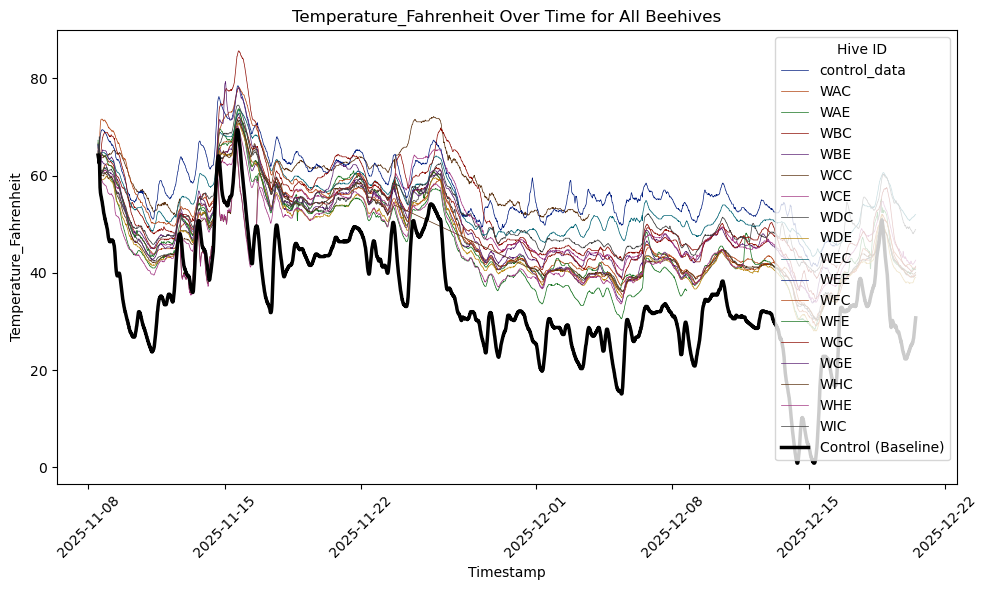

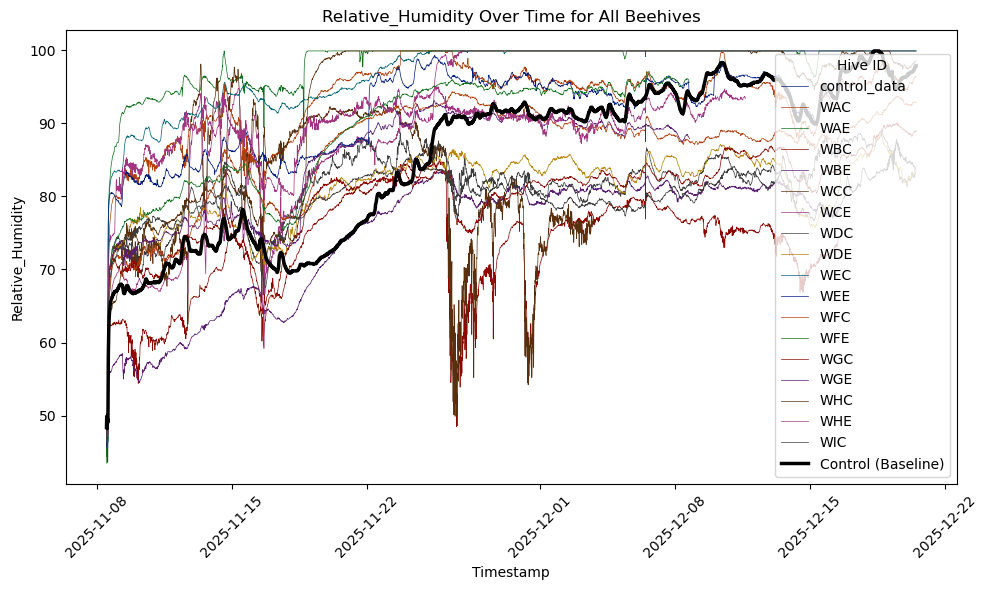

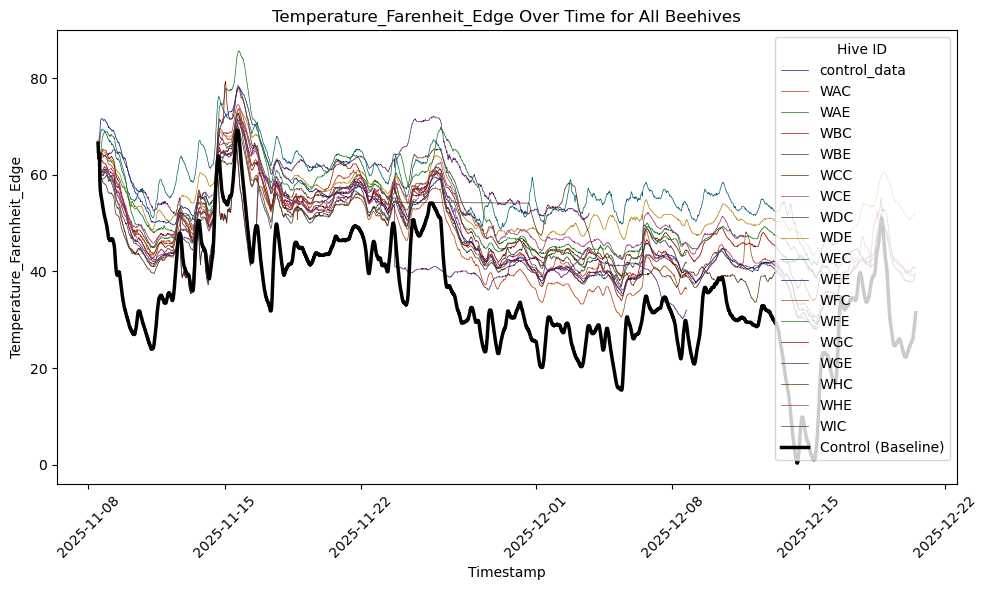

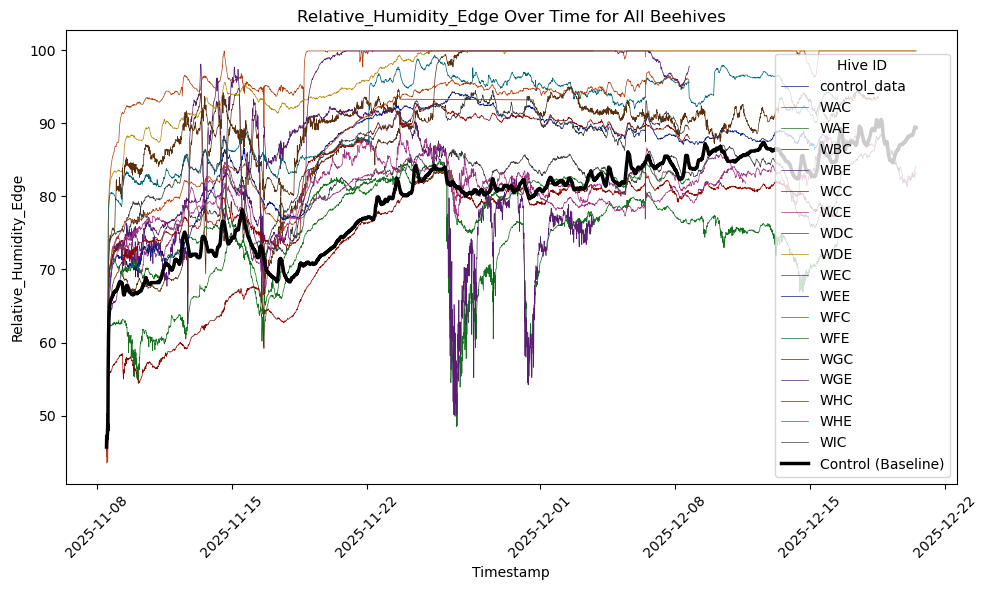

In [32]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the directory containing the CSV files
directory = 'data/Beehives_consolodated'

# Initialize an empty list to store the dataframes
dataframes = []

# Loop through each file in the directory
for filename in os.listdir(directory):
    if filename.endswith('.csv'):
        df = pd.read_csv(os.path.join(directory, filename))
        df.columns = df.columns.str.strip()  # Remove accidental whitespace from col names
        df['Hive_ID'] = filename.split('.')[0]
        dataframes.append(df)

# Concatenate all dataframes into a single dataframe
combined_df = pd.concat(dataframes, ignore_index=True)

# Strip whitespace from string values in Timestamp just in case
combined_df['Timestamp'] = pd.to_datetime(combined_df['Timestamp'])



# List of features to plot — only keep ones that actually exist in the dataframe
desired_features = ['Temperature_Fahrenheit', 'Relative_Humidity', 'Temperature_Farenheit_Edge', 'Relative_Humidity_Edge']
features = [f for f in desired_features if f in combined_df.columns]

# Warn about any missing features
missing = set(desired_features) - set(features)
if missing:
    print(f"\nWarning: These features were not found and will be skipped: {missing}")



control_df = pd.read_csv('data/Beehives_consolodated/control_data.csv')
control_df.columns = control_df.columns.str.strip()
control_df['Timestamp'] = pd.to_datetime(control_df['Timestamp'])

# Create a plot for each feature
for feature in features:
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=combined_df, x='Timestamp', y=feature, hue='Hive_ID',
                 marker='o', linewidth=0.5, markersize=0, palette='dark')
    
    # Overlay bold baseline from control data
    if feature in control_df.columns:
        plt.plot(control_df['Timestamp'], control_df[feature], 
                 color='black', linewidth=2.5, label='Control (Baseline)', zorder=5)

    plt.title(f'{feature} Over Time for All Beehives')
    plt.xlabel('Timestamp')
    plt.ylabel(feature)
    plt.legend(title='Hive ID')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [29]:
import os
import pandas as pd
import numpy as np
from scipy import stats

DIRECTORY    = 'data/Beehives_consolodated'
CONTROL_FILE = 'data/Beehives_consolodated/control_data.csv'
FEATURES     = ['Temperature_Fahrenheit', 'Relative_Humidity', 'Temperature_Farenheit_Edge', 'Relative_Humidity_Edge']

# Load beehives
dfs = []
for filename in os.listdir(DIRECTORY):
    if filename.endswith('.csv') and filename != 'control_data.csv':
        df = pd.read_csv(os.path.join(DIRECTORY, filename))
        df.columns = df.columns.str.strip()
        df['Hive_ID'] = filename.split('.')[0]
        dfs.append(df)
combined_df = pd.concat(dfs, ignore_index=True)

# Load control
control_df = pd.read_csv(CONTROL_FILE)
control_df.columns = control_df.columns.str.strip()

print('Hives loaded:', combined_df['Hive_ID'].unique())

Hives loaded: ['WAC' 'WAE' 'WBC' 'WBE' 'WCC' 'WCE' 'WDC' 'WDE' 'WEC' 'WEE' 'WFC' 'WFE'
 'WGC' 'WGE' 'WHC' 'WHE' 'WIC']


In [30]:
def cohens_d(a, b):
    pooled = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return (np.mean(a) - np.mean(b)) / pooled if pooled else np.nan

print(control_df.columns)
print(combined_df.columns)
for feature in FEATURES:
    if feature not in combined_df.columns or feature not in control_df.columns:
        print(f'Skipping {feature} — not found in data')
        continue

    ctrl = control_df[feature].dropna().values
    all_hive_vals = combined_df[feature].dropna().values
    n = min(len(all_hive_vals), len(ctrl))
    t_stat, t_p = stats.ttest_ind(all_hive_vals, ctrl, equal_var=False)

    result = pd.DataFrame([
        {
            'Hive'            : 'CONTROL',
            'Mean'            : round(np.mean(ctrl), 3),
            'Std'             : round(np.std(ctrl, ddof=1), 3),
            'Avg Fluctuation' : round(pd.Series(ctrl).diff().abs().mean(), 4),
            'Mean Δ Control'  : 0.0,
            'Pearson r'       : 1.0,
            'T p-value'       : '-',
            "Cohen's d"       : 0.0,
        },
        {
            'Hive'            : 'ALL HIVES (avg)',
            'Mean'            : round(np.mean(all_hive_vals), 3),
            'Std'             : round(np.std(all_hive_vals, ddof=1), 3),
            'Avg Fluctuation' : round(pd.Series(all_hive_vals).diff().abs().mean(), 4),
            'Mean Δ Control'  : round(np.abs(all_hive_vals[:n] - ctrl[:n]).mean(), 4),
            'Pearson r'       : round(stats.pearsonr(all_hive_vals[:n], ctrl[:n])[0], 4),
            'T p-value'       : round(t_p, 4),
            "Cohen's d"       : round(cohens_d(all_hive_vals, ctrl), 4),
        }
    ])

    print(f'\n── {feature} ──')
    display(result)

Index(['Timestamp', 'Temperature_Fahrenheit', 'Relative_Humidity',
       'Temperature_Farenheit_Edge', 'Relative_Humidity_Edge',
       'Temperature_Farenheit_Difference_C-E', 'Relative_Humidity_C-E',
       'Alive_or_Dead'],
      dtype='object')
Index(['Timestamp', 'Temperature_Fahrenheit', 'Relative_Humidity',
       'Temperature_Farenheit_Edge', 'Relative_Humidity_Edge',
       'Temperature_Farenheit_Difference_C-E', 'Relative_Humidity_C-E',
       'Alive_or_Dead', 'Difference In Temperature From Empty Center',
       'Difference In Temperature From Empty Edge',
       'Difference In Humidity From Empty Center',
       'Difference In Humidity From Empty Edge', 'Hive_ID'],
      dtype='object')

── Temperature_Fahrenheit ──


,Hive,Mean,Std,Avg Fluctuation,Mean Δ Control,Pearson r,T p-value,Cohen's d
0,CONTROL,34.485,11.514,0.1896,0.0000,1.0000,-,0.000
1,ALL HIVES (avg),49.936,8.972,0.0942,13.4705,0.8875,0.0,1.497



── Relative_Humidity ──


,Hive,Mean,Std,Avg Fluctuation,Mean Δ Control,Pearson r,T p-value,Cohen's d
0,CONTROL,85.554,10.575,0.0550,0.0000,1.0000,-,0.0000
1,ALL HIVES (avg),86.353,10.015,0.1461,8.3502,0.6677,0.0,0.0776



── Temperature_Farenheit_Edge ──


,Hive,Mean,Std,Avg Fluctuation,Mean Δ Control,Pearson r,T p-value,Cohen's d
0,CONTROL,34.477,11.563,0.1948,0.0000,1.0000,-,0.000
1,ALL HIVES (avg),50.471,9.010,0.0975,12.6462,0.9294,0.0,1.543



── Relative_Humidity_Edge ──


,Hive,Mean,Std,Avg Fluctuation,Mean Δ Control,Pearson r,T p-value,Cohen's d
0,CONTROL,79.694,6.499,0.0656,0.0000,1.0000,-,0.0000
1,ALL HIVES (avg),85.433,9.927,0.1507,18.6197,0.7421,0.0,0.6841


In [ ]:
#linear regression model on the difference in temperature
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

data = pd.read_csv('compiled_beehive_data.csv')
data.head()
X = data[['Difference_']]

,Name,Timestamp,Temperature_Fahrenheit,Relative_Humidity,Temperature_Farenheit_Edge,Relative_Humidity_Edge,Temperature_Farenheit_Difference_C-E,Relative_Humidity_C-E,Alive_or_Dead,Difference In Temperature From Empty Center,Difference In Temperature From Empty Edge,Difference In Humidity From Empty Center,Difference In Humidity From Empty Edge
0,WAC,2025-11-08 12:00:00,66.74,44.9,64.94,46.3,1.80,-1.4,1,2.52,-1.62,-3.5,0.6
1,WAC,2025-11-08 12:15:00,65.66,46.7,64.04,48.1,1.62,-1.4,1,1.80,-1.26,-3.2,0.9
2,WAC,2025-11-08 12:30:00,64.76,46.1,63.50,47.1,1.26,-1.0,1,1.08,-1.08,-2.2,0.3
3,WAC,2025-11-08 12:45:00,64.04,46.5,62.24,48.5,1.80,-2.0,1,0.54,-1.98,-1.7,1.5
4,WAC,2025-11-08 13:00:00,63.32,47.1,62.24,48.5,1.08,-1.4,1,0.18,-1.62,-1.6,1.2
